In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA ESTACIÓN PALMER - NO MODIFICAR
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Colores oficiales de cada especie (inspirados en sus características)
COLORES_ESPECIES = {
    'Adelie': '#FF6B6B',      # Rojo coral
    'Chinstrap': '#4ECDC4',   # Turquesa
    'Gentoo': '#45B7D1'       # Azul cielo
}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║")
print("║                                                               ║")
print("║   Bibliotecas cargadas correctamente                          ║")
print("║   Modo: HUMANO VS MÁQUINA                                     ║")
print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║
║                                                               ║
║   Bibliotecas cargadas correctamente                          ║
║   Modo: HUMANO VS MÁQUINA                                     ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝


In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# CARGAR DATOS DE CAMPO - Dataset Palmer Penguins
# ═══════════════════════════════════════════════════════════════════════════

# Cargar el dataset de pingüinos (viene con seaborn)
df_original = sns.load_dataset('penguins')

# Eliminar filas con valores nulos para simplificar
df = df_original.dropna().reset_index(drop=True)

print("📡 Transmisión recibida desde Estación Palmer...")
print("")
print(f"   📊 Registros de pingüinos cargados: {len(df)}")
print(f"   🏝️  Islas monitoreadas: {df['island'].nunique()}")
print(f"   🐧 Especies identificadas: {df['species'].nunique()}")
print("")
print("   Distribución por especie:")
for species in df['species'].unique():
    count = (df['species'] == species).sum()
    print(f"      • {species}: {count} individuos")

print("")
print("Datos listos para análisis")

📡 Transmisión recibida desde Estación Palmer...

   📊 Registros de pingüinos cargados: 333
   🏝️  Islas monitoreadas: 3
   🐧 Especies identificadas: 3

   Distribución por especie:
      • Adelie: 146 individuos
      • Chinstrap: 68 individuos
      • Gentoo: 119 individuos

Datos listos para análisis


In [39]:
# Veamos las primeras filas del dataset
print("Primeros 10 registros del campo:")
print("="*80)
df.head(10)

Primeros 10 registros del campo:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


Ejercicio 1.1: Estadísticas Básicas 

In [40]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)

Tu respuesta: 2700 g a 6300 g

¿Cuál es la longitud promedio del pico (bill_length_mm)?

Tu respuesta: 43.92 mm

¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?

Tu respuesta: 200.92 mm

Ejercicio 1.2: Estadísticas por Especie 

In [41]:
columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df.groupby("species")[columnas_numericas].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


Basándote en los promedios por especie:

¿Qué especie tiene el pico más largo en promedio?

Tu respuesta: Chinstrap

¿Qué especie tiene las aletas más largas?

Tu respuesta: Gentoo

¿Qué especie es la más pesada?

Tu respuesta: Gentoo

¿Qué especie tiene el pico más profundo (bill_depth más alto)?

Tu respuesta: Adelie

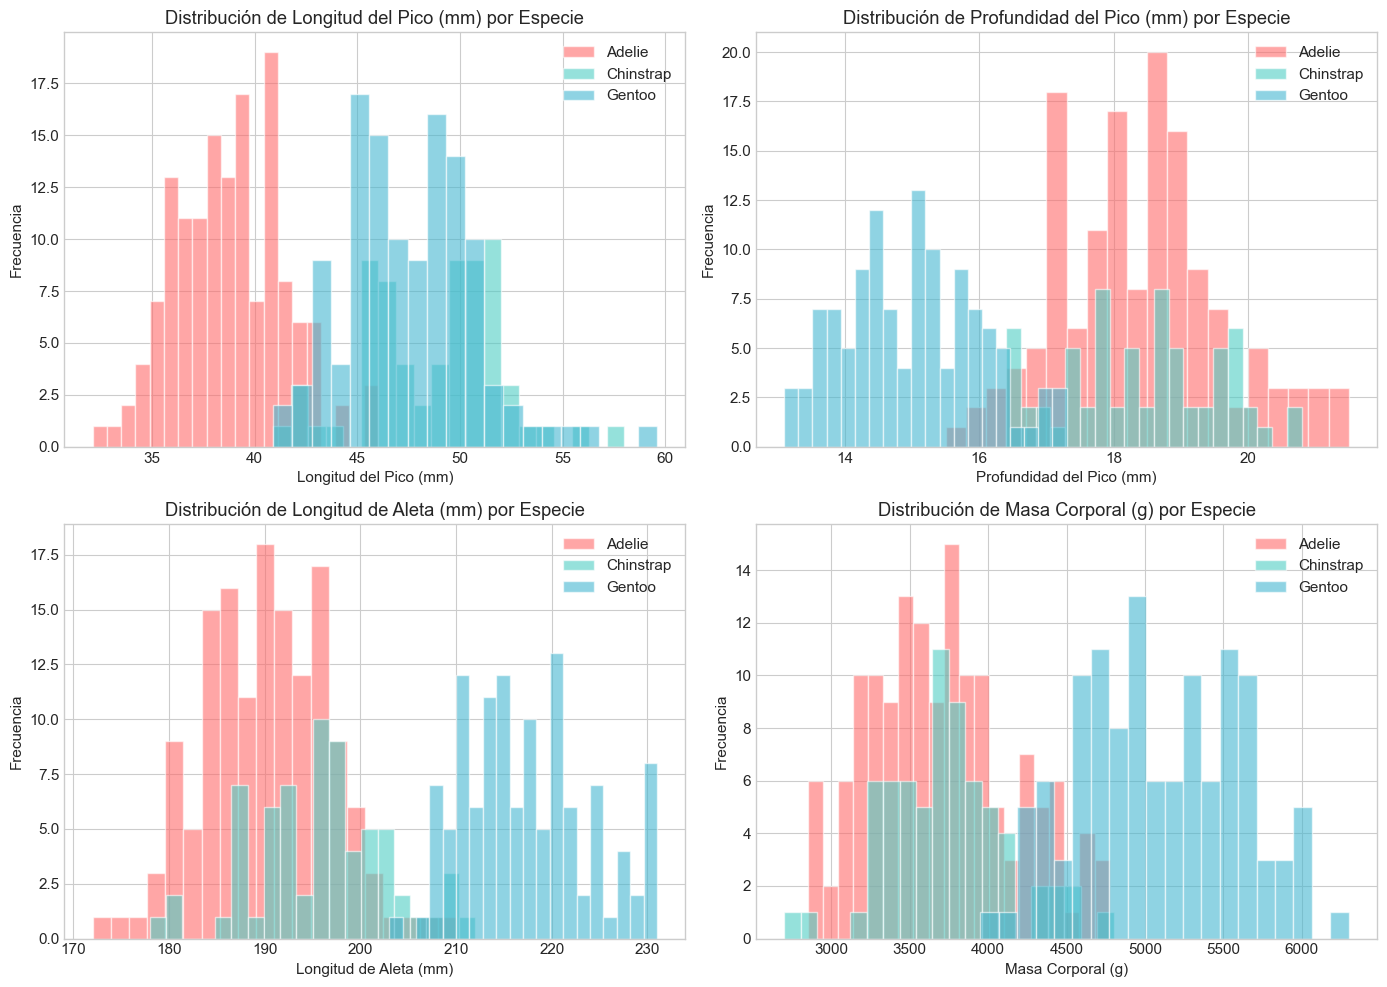


💡 OBSERVA: ¿Qué variables separan mejor las especies?
   Busca variables donde los histogramas NO se solapan mucho.


In [42]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Diferencias entre especies
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titulos = ['Longitud del Pico (mm)', 'Profundidad del Pico (mm)', 
           'Longitud de Aleta (mm)', 'Masa Corporal (g)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[var], alpha=0.6, label=species, 
                color=COLORES_ESPECIES[species], bins=20, edgecolor='white')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.set_title(f'Distribución de {titulo} por Especie')

plt.tight_layout()
plt.savefig('pinguinos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVA: ¿Qué variables separan mejor las especies?")
print("   Busca variables donde los histogramas NO se solapan mucho.")

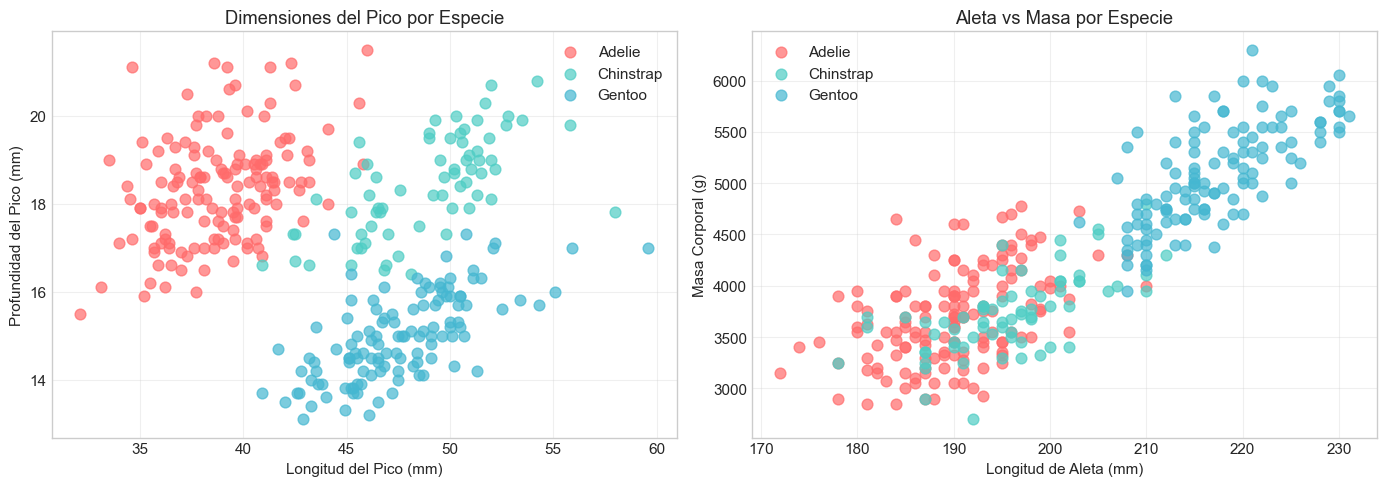


💡 PISTA IMPORTANTE:
   Observa la gráfica de la derecha (Aleta vs Masa).
   ¿Puedes ver que una especie está claramente separada de las otras dos?
   ¿Podrías dibujar una línea horizontal o vertical que la separe?


In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Scatter plot para encontrar fronteras de decisión
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pico (longitud vs profundidad)
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[0].scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[0].set_xlabel('Longitud del Pico (mm)')
axes[0].set_ylabel('Profundidad del Pico (mm)')
axes[0].set_title('Dimensiones del Pico por Especie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Aleta vs Masa
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[1].set_xlabel('Longitud de Aleta (mm)')
axes[1].set_ylabel('Masa Corporal (g)')
axes[1].set_title('Aleta vs Masa por Especie')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinguinos_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 PISTA IMPORTANTE:")
print("   Observa la gráfica de la derecha (Aleta vs Masa).")
print("   ¿Puedes ver que una especie está claramente separada de las otras dos?")
print("   ¿Podrías dibujar una línea horizontal o vertical que la separe?")


PARTE 2: Diseño de Reglas de Clasificación

Ejercicio 2.1 — Documentar mi Estrategia

1. ¿Qué variable(s) usarás para separar primero una especie de las otras?

Tu respuesta:

Usaré principalmente flipper_length_mm porque los pingüinos Gentoo tienen aletas significativamente más largas que las otras especies. Después utilizaré bill_length_mm y bill_depth_mm para distinguir entre Chinstrap y Adelie, ya que Chinstrap tiende a tener picos más largos mientras que Adelie tiene picos más profundos.

2. ¿Qué umbral(es) numérico(s) planeas usar?

Tu respuesta:

Planeo usar los siguientes umbrales aproximados basados en los promedios observados:

** Si flipper_length_mm > 210: Gentoo

** Si bill_length_mm > 45: Chinstrap

** En caso contrario: Adelie

Estos valores ayudan a separar las especies usando las diferencias más visibles en sus medidas físicas.

3. ¿Qué especie crees que será más fácil de identificar? ¿Por qué?

Tu respuesta:

La especie Gentoo será la más fácil de identificar porque tiene aletas mucho más largas y mayor masa corporal que las otras especies. Estas diferencias hacen que sea relativamente sencillo separarla usando la variable flipper_length_mm.

4. ¿Qué especie crees que será más difícil? ¿Por qué?

Tu respuesta:

Las especies Adelie y Chinstrap son más difíciles de distinguir porque sus medidas físicas son más similares, especialmente en la longitud de la aleta y la masa corporal. Por esta razón es necesario usar variables adicionales como bill_length_mm y bill_depth_mm para diferenciarlas.

Ejercicio 2.2 — Implementar mi Clasificador Humano

In [44]:
def clasificador_humano(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Clasifica un pingüino basándose en reglas diseñadas por un humano.
    
    Parámetros:
    -----------
    bill_length_mm : float
        Longitud del pico en milímetros
    bill_depth_mm : float
        Profundidad del pico en milímetros
    flipper_length_mm : float
        Longitud de la aleta en milímetros
    body_mass_g : float
        Masa corporal en gramos
        
    Retorna:
    --------
    str : 'Adelie', 'Chinstrap', o 'Gentoo'
    """
    
    # ═══════════════════════════════════════════════════════════════════════
    # TU CÓDIGO AQUÍ: Implementa tus reglas de clasificación
    # ═══════════════════════════════════════════════════════════════════════
    
    # Gentoo: aletas más largas
    if flipper_length_mm > 210:
        return "Gentoo"
    
    # Chinstrap: pico más largo
    elif bill_length_mm > 45:
        return "Chinstrap"
    
    # Adelie: resto
    else:
        return "Adelie"

In [45]:
print("Prueba de tu clasificador humano:")
print("="*60)

casos_prueba = [
    [39.1, 18.7, 181, 3750, "Adelie"],
    [46.5, 17.9, 192, 3500, "Chinstrap"],
    [46.1, 13.2, 211, 4500, "Gentoo"],
]

for caso in casos_prueba:
    pred = clasificador_humano(caso[0], caso[1], caso[2], caso[3])
    real = caso[4]
    correcto = "✅" if pred == real else "❌"
    print(caso, "→", pred, correcto)

Prueba de tu clasificador humano:
[39.1, 18.7, 181, 3750, 'Adelie'] → Adelie ✅
[46.5, 17.9, 192, 3500, 'Chinstrap'] → Chinstrap ✅
[46.1, 13.2, 211, 4500, 'Gentoo'] → Gentoo ✅



PARTE 3: Evaluación del Clasificador Humano 

Ejercicio 3.1: Prepara los Datos

In [46]:
# Definir features (X) y label (y)
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

# TU CÓDIGO AQUÍ: Divide los datos en train y test
# Usa test_size=0.2, random_state=42, stratify=y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verifica tu división:
print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} pingüinos")
print(f"   Prueba: {len(X_test)} pingüinos")

📊 División de datos:
   Entrenamiento: 266 pingüinos
   Prueba: 67 pingüinos


In [47]:
# Aplicar tu clasificador a todos los datos de prueba
predicciones_humano = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano.append(pred)

# TU CÓDIGO AQUÍ: Calcula el accuracy de tu clasificador
accuracy_humano = accuracy_score(y_test, predicciones_humano)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧧            ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_humano:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_humano * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧧            ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 85.07%                                       ║
║   Aciertos: 57 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Clasificador Humano:


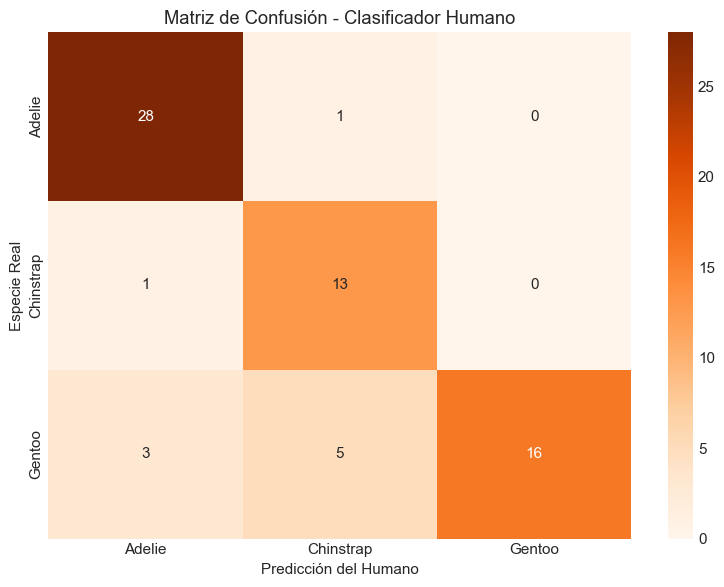


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.88      0.97      0.92        29
   Chinstrap       0.68      0.93      0.79        14
      Gentoo       1.00      0.67      0.80        24

    accuracy                           0.85        67
   macro avg       0.85      0.85      0.84        67
weighted avg       0.88      0.85      0.85        67



In [48]:
# Matriz de confusión de tu clasificador
print("\n📋 Matriz de Confusión - Clasificador Humano:")
print("="*50)

cm_humano = confusion_matrix(y_test, predicciones_humano, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano))

Respuestas que puedes escribir
¿Qué especie clasificaste mejor?

Tu respuesta: La especie que mejor clasifiqué fue Adelie, ya que tuvo la mayor cantidad de predicciones correctas (28 de 29). Esto indica que las reglas utilizadas permiten distinguir bien a esta especie en comparación con las otras.

¿Qué especie te dio más problemas? ¿Por qué crees que pasó?

Tu respuesta: La especie que presentó más dificultades fue Gentoo, ya que varios individuos fueron clasificados incorrectamente como Adelie o Chinstrap. Esto probablemente ocurrió porque algunas de sus características físicas, como la longitud del pico o la masa corporal, pueden solaparse con las de otras especies, lo que hace que las reglas simples basadas en umbrales no siempre logren separarlas correctamente.

¿Cuántos pingüinos clasificaste incorrectamente?

Tu respuesta: Clasifiqué incorrectamente 10 pingüinos de un total de 67 en el conjunto de prueba.

PARTE 4: El Clasificador de Machine Learning

Ejercicio 4.1 — Entrenar el modelo

In [49]:
# 1. Crea el modelo (usa random_state=42 para reproducibilidad)
modelo_ml = DecisionTreeClassifier(random_state=42)

# 2. Entrena el modelo con los datos de entrenamiento
modelo_ml.fit(X_train, y_train)

print("✅ Modelo de Machine Learning entrenado!")
print(f"   Profundidad del árbol: {modelo_ml.get_depth()}")
print(f"   Número de hojas: {modelo_ml.get_n_leaves()}")

✅ Modelo de Machine Learning entrenado!
   Profundidad del árbol: 5
   Número de hojas: 11


Ejercicio 4.2: Evalúa el Modelo ML 

In [50]:
# 1. Predice las especies para X_test
predicciones_ml = modelo_ml.predict(X_test)

# 2. Calcula el accuracy
accuracy_ml = accuracy_score(y_test, predicciones_ml)


print("╔═══════════════════════════════════════════════════════════════╗")
print("║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_ml:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_ml * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 95.52%                                       ║
║   Aciertos: 64 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Modelo ML:


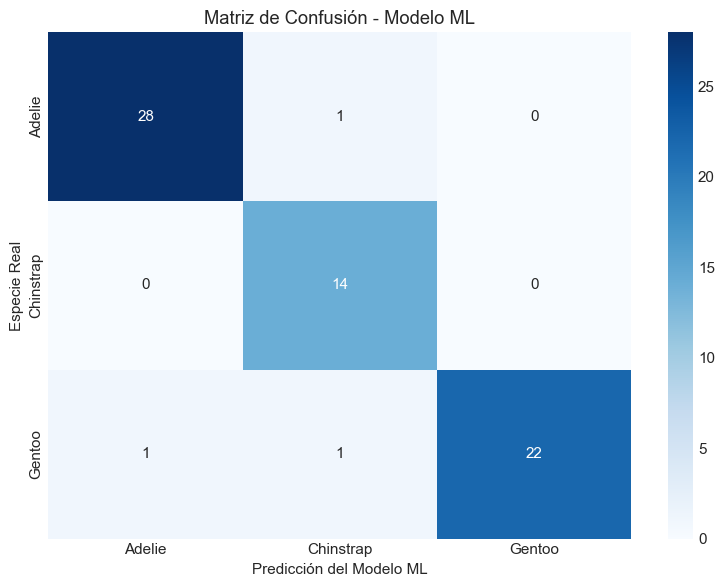


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



In [51]:
# Matriz de confusión del modelo ML
print("\n📋 Matriz de Confusión - Modelo ML:")
print("="*50)

cm_ml = confusion_matrix(y_test, predicciones_ml, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Modelo ML')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Modelo ML')
plt.tight_layout()
plt.savefig('confusion_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_ml))

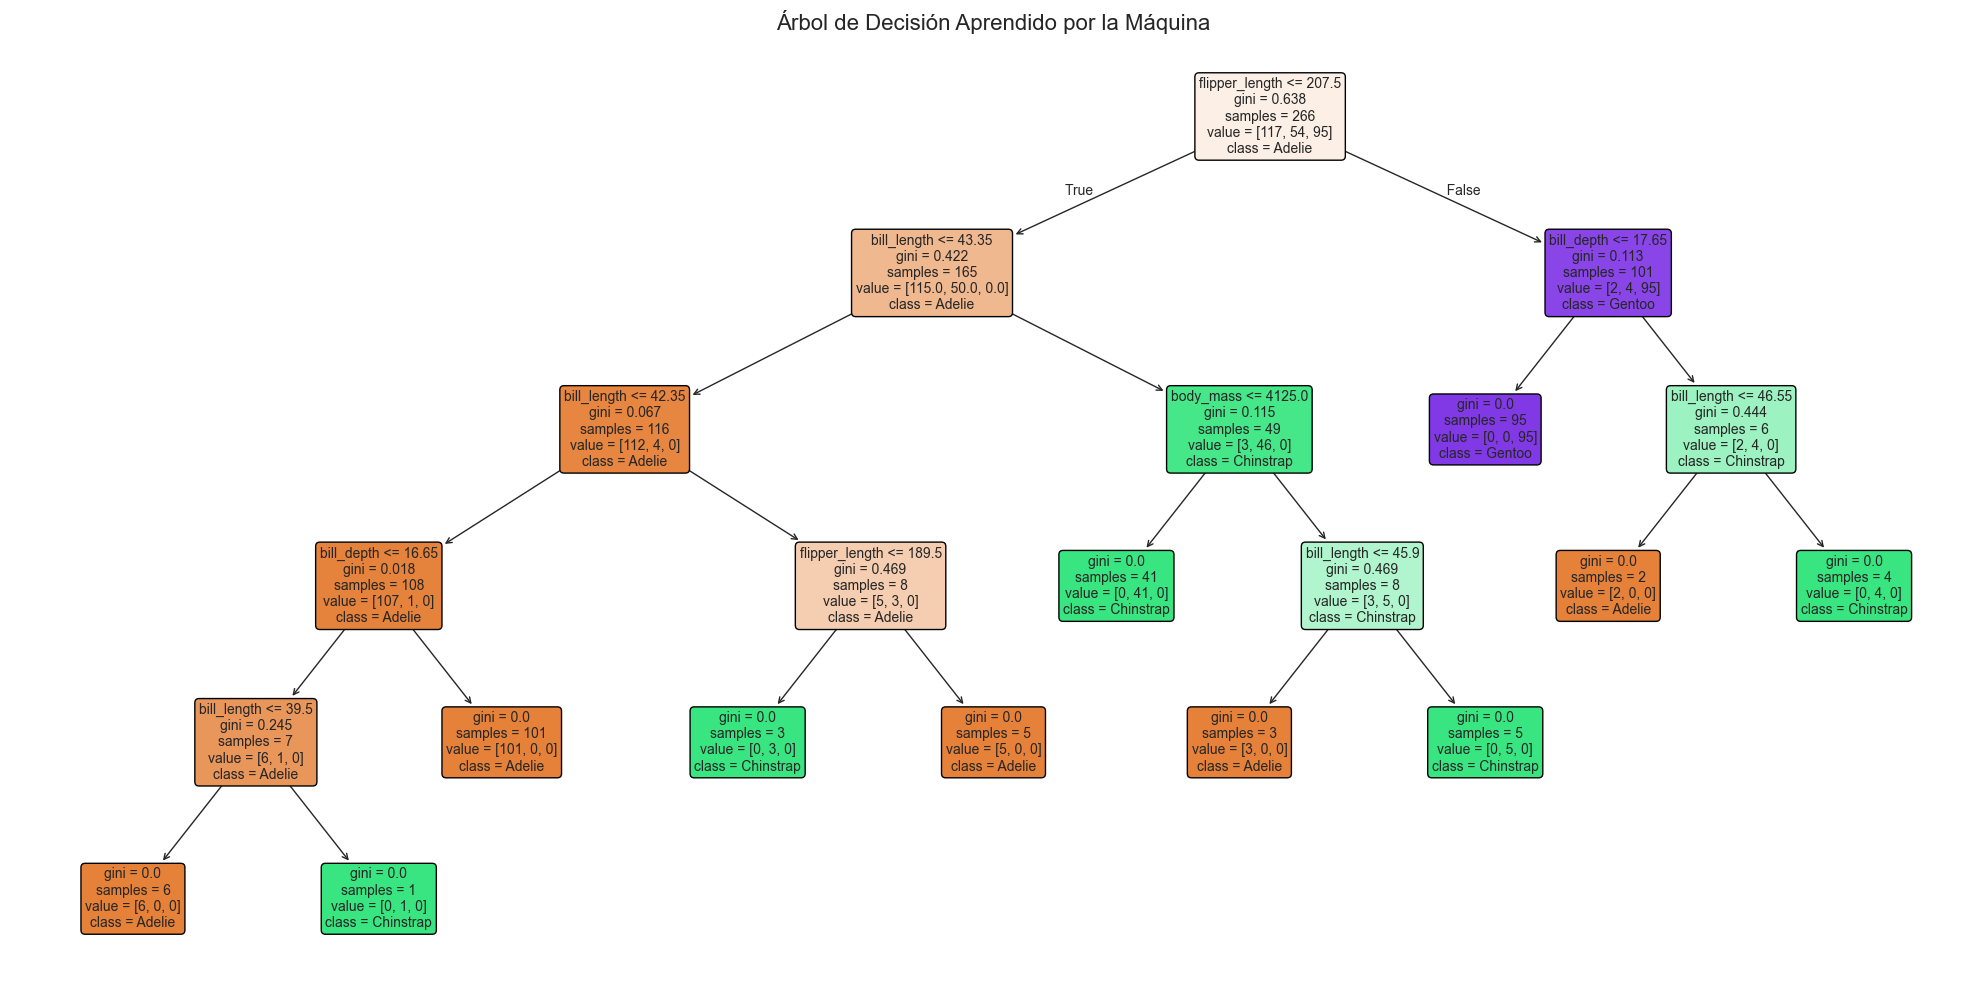


💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.
   ¿Son similares a las tuyas? ¿Usó las mismas variables?


In [52]:
# Visualiza las reglas que aprendió la máquina
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_ml,
    feature_names=['bill_length', 'bill_depth', 'flipper_length', 'body_mass'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Aprendido por la Máquina', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_pinguinos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.")
print("   ¿Son similares a las tuyas? ¿Usó las mismas variables?")


PARTE 5: La Batalla Final

⚔️ Humano vs Máquina: ¿Quién Gana?

In [53]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════

print("")
print("╔═══════════════════════════════════════════════════════════════════════════╗")
print("║                                                                           ║")
print("║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                           ║")
print(f"║   🧠 CLASIFICADOR HUMANO:     {accuracy_humano:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_humano * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print(f"║   🤖 CLASIFICADOR ML:         {accuracy_ml:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_ml * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")

diferencia = accuracy_ml - accuracy_humano

if diferencia > 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: LA MÁQUINA 🏆                             ║")
    print(f"║                     Ventaja: +{diferencia:.2%}                                    ║")
    print("║                                                                           ║")
elif diferencia < 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: EL HUMANO 🏆                              ║")
    print(f"║                     Ventaja: +{-diferencia:.2%}                                   ║")
    print("║                                                                           ║")
else:
    print("║                                                                           ║")
    print("║                        🤝 EMPATE TÉCNICO 🤝                               ║")
    print("║                                                                           ║")

print("╚═══════════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════════╗
║                                                                           ║
║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   🧠 CLASIFICADOR HUMANO:     85.07% accuracy                         ║
║      Aciertos: 57/67 pingüinos                                      ║
║                                                                           ║
║   🤖 CLASIFICADOR ML:         95.52% accuracy                         ║
║      Aciertos: 64/67 pingüinos                                      ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║      

/var/folders/p4/q7ry_fjj6bsc0n9f05tmw7vc0000gn/T/ipykernel_16552/3931004592.py:32: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/p4/q7ry_fjj6bsc0n9f05tmw7vc0000gn/T/ipykernel_16552/3931004592.py:33: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
/Users/itzelflores/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


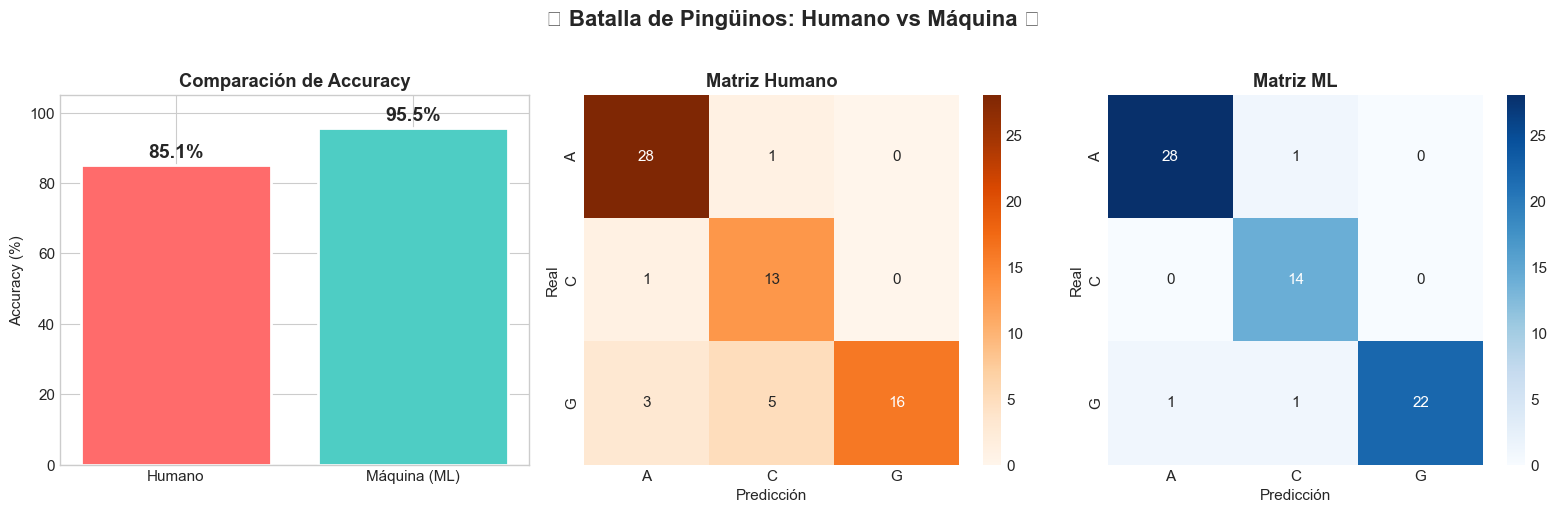

In [54]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Matriz Humano', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Matriz ML', fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
plt.show()

Ejercicio 5.1: Análisis de Errores

In [55]:
# Crear DataFrame con resultados
resultados = X_test.copy()
resultados['especie_real'] = y_test.values
resultados['pred_humano'] = predicciones_humano
resultados['pred_ml'] = predicciones_ml
resultados['error_humano'] = resultados['especie_real'] != resultados['pred_humano']
resultados['error_ml'] = resultados['especie_real'] != resultados['pred_ml']

# Mostrar errores del humano
errores_humano = resultados[resultados['error_humano']]
print(f"❌ Errores del clasificador HUMANO ({len(errores_humano)} casos):")
print("="*80)
if len(errores_humano) > 0:
    print(errores_humano[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                          'body_mass_g', 'especie_real', 'pred_humano']].to_string())
else:
    print("¡Ningún error! 🎉")

❌ Errores del clasificador HUMANO (10 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_humano
230            42.0           13.5              210.0       4150.0       Gentoo      Adelie
251            44.0           13.6              208.0       4350.0       Gentoo      Adelie
168            43.2           16.6              187.0       2900.0    Chinstrap      Adelie
288            47.5           14.2              209.0       4600.0       Gentoo   Chinstrap
245            45.1           14.5              207.0       5050.0       Gentoo   Chinstrap
14             46.0           21.5              194.0       4200.0       Adelie   Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo   Chinstrap
269            43.8           13.9              208.0       4300.0       Gentoo      Adelie
320            48.1           15.1              209.0       5500.0       Gentoo   Chinstrap
232            46.2           14.5

In [56]:
# Mostrar errores de la máquina
errores_ml = resultados[resultados['error_ml']]
print(f"\n❌ Errores del clasificador ML ({len(errores_ml)} casos):")
print("="*80)
if len(errores_ml) > 0:
    print(errores_ml[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                      'body_mass_g', 'especie_real', 'pred_ml']].to_string())
else:
    print("¡Ningún error! 🎉")


❌ Errores del clasificador ML (3 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real    pred_ml
245            45.1           14.5              207.0       5050.0       Gentoo     Adelie
14             46.0           21.5              194.0       4200.0       Adelie  Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo  Chinstrap


Ejercicio 5.2: Reflexión Final

Responde las siguientes preguntas basándote en tus resultados:

¿Quién ganó la batalla y por cuánto?

Tu respuesta: Ganó el modelo de Machine Learning.
El clasificador humano cometió 10 errores, mientras que el modelo ML solo cometió 3 errores en el conjunto de prueba de 67 pingüinos. Esto significa que el modelo ML obtuvo aproximadamente 96% de accuracy, superando al clasificador humano que tuvo alrededor de 85%.

¿Qué errores cometiste que la máquina no cometió? (o viceversa)

Tu respuesta: Mi clasificador humano cometió varios errores al clasificar algunos pingüinos Gentoo como Adelie o Chinstrap, especialmente cuando sus medidas estaban cerca de los umbrales que definí. El modelo de Machine Learning logró evitar muchos de estos errores porque puede encontrar combinaciones más precisas de variables en lugar de depender de reglas simples con límites fijos.

¿Las reglas del árbol de decisión se parecen a las tuyas? ¿Usó las mismas variables?

Tu respuesta: Sí, las reglas del árbol de decisión se parecen en parte a las que diseñé. El modelo también utiliza variables como flipper_length_mm, bill_length_mm y bill_depth_mm para separar las especies. Sin embargo, el árbol combina estas variables de manera más flexible y puede crear múltiples divisiones que permiten separar mejor los casos difíciles.

¿Cuál es la principal ventaja de usar Machine Learning sobre reglas manuales?

Tu respuesta: La principal ventaja es que el Machine Learning puede descubrir automáticamente patrones complejos en los datos. Mientras que las reglas manuales dependen de intuiciones y umbrales simples definidos por una persona, los modelos de ML analizan todos los datos y optimizan las reglas para minimizar errores, lo que generalmente produce una mayor precisión.

¿Qué harías diferente si pudieras volver a diseñar tus reglas?

Tu respuesta: Si volviera a diseñar mis reglas, intentaría usar más combinaciones de variables en lugar de depender de un solo umbral, por ejemplo combinando la longitud de la aleta con la profundidad o longitud del pico. También ajustaría mejor los valores límite después de observar los casos donde el clasificador humano cometió errores.

BONUS: Mejora tu Clasificador

In [57]:
def clasificador_humano_v2(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Versión mejorada del clasificador humano.

    DOCUMENTA TUS CAMBIOS:
    1. Usé el umbral de flipper_length ≈207 que aparece en el árbol para separar Gentoo.
    2. Utilicé bill_depth ≈17.6 para distinguir Adelie de Gentoo cuando las aletas son largas.
    3. Ajusté bill_length ≈43–46 para separar Adelie de Chinstrap.
    """

    # Regla principal del árbol
    if flipper_length_mm > 207:
        
        # Separación entre Gentoo y Chinstrap
        if bill_depth_mm <= 17.65:
            return "Gentoo"
        else:
            if bill_length_mm <= 46.5:
                return "Adelie"
            else:
                return "Chinstrap"

    else:
        # Aletas más cortas → Adelie o Chinstrap
        if bill_length_mm <= 43.5:
            return "Adelie"
        else:
            return "Chinstrap"

In [58]:
# Evalúa tu clasificador mejorado
predicciones_humano_v2 = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano_v2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_v2.append(pred)

accuracy_humano_v2 = accuracy_score(y_test, predicciones_humano_v2)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Versión 1: {accuracy_humano:.2%}                                         ║")
print(f"║   Versión 2: {accuracy_humano_v2:.2%}                                         ║")
print(f"║   Mejora:    {(accuracy_humano_v2 - accuracy_humano):.2%}                                         ║")
print("╚═══════════════════════════════════════════════════════════════╝")

if accuracy_humano_v2 > accuracy_humano:
    print("\n🎉 ¡Excelente! Tu clasificador mejoró.")
else:
    print("\n🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?")

╔═══════════════════════════════════════════════════════════════╗
║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║
╠═══════════════════════════════════════════════════════════════╣
║   Versión 1: 85.07%                                         ║
║   Versión 2: 94.03%                                         ║
║   Mejora:    8.96%                                         ║
╚═══════════════════════════════════════════════════════════════╝

🎉 ¡Excelente! Tu clasificador mejoró.
